# Importing Libraries

In [222]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
from scipy.stats import norm
import math
import numpy as np
import os

# Importing Datasets

In [224]:
dict={}
for i in os.listdir('C:/Users/tatba/OneDrive/Desktop/PWSkills_Data_Analytics_with_AI/Self_Practise/Maven_Fuzzy_Factory'):
    if '.csv' in i:
        print(i)
        dict[os.path.splitext(os.path.basename(i))[0]]=pd.read_csv(os.path.join('C:/Users/tatba/OneDrive/Desktop/PWSkills_Data_Analytics_with_AI/Self_Practise/Maven_Fuzzy_Factory',i))

maven_fuzzy_factory_data_dictionary.csv
orders.csv
order_items.csv
order_item_refunds.csv
products.csv
website_pageviews.csv
website_sessions.csv


# Inspecting Data Quality

## Orders Table

In [227]:
orders=dict['orders']
print(orders.shape)
print("\n")
print(orders.info())
print("\n")
print(orders.describe())
print("\n")
print(orders.isnull().sum())

(32313, 8)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  object 
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.0+ MB
None


           order_id  website_session_id        user_id  primary_product_id  \
count  32313.000000        32313.000000   32313.000000        32313.000000   
mean   16157.000000       258292.288707  215691.622629            1.392474   
std     9328.103961       132427.649842  108402.203189            0.732277   
min     

## Order_Items Table

In [229]:
order_items=dict['order_items']
print(order_items.shape)
print("\n")
print(order_items.info())
print("\n")
print(order_items.describe())
print("\n")
print(order_items.isnull().sum())

(40025, 7)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  object 
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float64
 6   cogs_usd         40025 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 2.1+ MB
None


       order_item_id      order_id    product_id  is_primary_item  \
count   40025.000000  40025.000000  40025.000000     40025.000000   
mean    20013.000000  17121.957502      1.770019         0.807320   
std     11554.366599   9053.765867      1.085561         0.394408   
min         1.000000      1.000000      1.000000         0.000000   
25%     10007.000000   9871.000000      1.000000   

## Order_Item_Refunds Table

In [231]:
order_item_refunds=dict['order_item_refunds']
print(order_item_refunds.shape)
print("\n")
print(order_item_refunds.info())
print("\n")
print(order_item_refunds.describe())
print("\n")
print(order_item_refunds.isnull().sum())

(1731, 5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1731 entries, 0 to 1730
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_item_refund_id  1731 non-null   int64  
 1   created_at            1731 non-null   object 
 2   order_item_id         1731 non-null   int64  
 3   order_id              1731 non-null   int64  
 4   refund_amount_usd     1731 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 67.7+ KB
None


       order_item_refund_id  order_item_id      order_id  refund_amount_usd
count           1731.000000    1731.000000   1731.000000        1731.000000
mean             866.000000   18472.214905  15868.242057          49.300225
std              499.840975   11438.074606   9096.061945           4.956015
min                1.000000      57.000000     57.000000          29.990000
25%              433.500000    7417.000000   7412.000000          49.990000

## Website_Sessions Table

In [233]:
website_sessions=dict['website_sessions']
print(website_sessions.shape)
print("\n")
print(website_sessions.info())
print("\n")
print(website_sessions.describe())
print("\n")
print(website_sessions.isnull().sum())

(472871, 9)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  472871 non-null  int64 
 1   created_at          472871 non-null  object
 2   user_id             472871 non-null  int64 
 3   is_repeat_session   472871 non-null  int64 
 4   utm_source          389543 non-null  object
 5   utm_campaign        389543 non-null  object
 6   utm_content         389543 non-null  object
 7   device_type         472871 non-null  object
 8   http_referer        432954 non-null  object
dtypes: int64(3), object(6)
memory usage: 32.5+ MB
None


       website_session_id        user_id  is_repeat_session
count       472871.000000  472871.000000      472871.000000
mean        236436.000000  198037.970163           0.166119
std         136506.243908  111992.997798           0.372188
min              1.000000       1.00000

## Website_Pageviews Table

In [235]:
website_pageviews=dict['website_pageviews']
print(website_pageviews.shape)
print("\n")
print(website_pageviews.info())
print("\n")
print(website_pageviews.describe())
print("\n")
print(website_pageviews.isnull().sum())

(1048575, 4)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   website_pageview_id  1048575 non-null  int64 
 1   created_at           1048575 non-null  object
 2   website_session_id   1048575 non-null  int64 
 3   pageview_url         1048575 non-null  object
dtypes: int64(2), object(2)
memory usage: 32.0+ MB
None


       website_pageview_id  website_session_id
count         1.048575e+06        1.048575e+06
mean          5.242880e+05        2.174518e+05
std           3.026977e+05        1.208389e+05
min           1.000000e+00        1.000000e+00
25%           2.621445e+05        1.137630e+05
50%           5.242880e+05        2.205110e+05
75%           7.864315e+05        3.223905e+05
max           1.048575e+06        4.219560e+05


website_pageview_id    0
created_at             0
website_session_id     0
pageview_

# Data Transformation

## Merging Orders, Order_Items, and Order_Item_Refunds Tables

In [238]:
## Orders, Order_Items and Order_Item_Refunds are three normalized table of the one fact table; therefore, joining them for ease of work.

In [239]:
order_details=pd.merge(order_items,orders,on='order_id',how='inner')
order_details.drop(columns=['created_at_y'],inplace=True)
order_details=order_details.rename(columns={'created_at_x':'created_at','price_usd_x':'item_price_usd','cogs_usd_x':'item_cogs_usd','price_usd_y':'order_price_usd','price_cogs_y':'order_cogs_usd'})
print(order_details.shape)
order_details=pd.merge(order_details,order_item_refunds,on='order_item_id',how='left')
order_details=order_details.rename(columns={'created_at_x':'created_at','created_at_y':'refund_created_at'})
print(order_details.shape)

(40025, 13)
(40025, 17)


## Imputing Null Values

In [241]:
order_details['order_item_refund_id'].fillna(0,inplace=True)
order_details['refund_amount_usd'].fillna(0,inplace=True)
order_details.drop(columns=['order_id_y'],inplace=True)
order_details=order_details.rename(columns={'order_id_x':'order_id','cogs_usd_y':'order_cogs_usd'})

C:\Users\tatba\AppData\Local\Temp\ipykernel_33632\1491324673.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  order_details['order_item_refund_id'].fillna(0,inplace=True)
C:\Users\tatba\AppData\Local\Temp\ipykernel_33632\1491324673.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [242]:
order_details

,order_item_id,created_at,order_id,product_id,is_primary_item,item_price_usd,item_cogs_usd,website_session_id,user_id,primary_product_id,items_purchased,order_price_usd,order_cogs_usd,order_item_refund_id,refund_created_at,refund_amount_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,20,20,1,1,49.99,19.49,0.0,NaN,0.0
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,104,104,1,1,49.99,19.49,0.0,NaN,0.0
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,147,147,1,1,49.99,19.49,0.0,NaN,0.0
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,160,160,1,1,49.99,19.49,0.0,NaN,0.0
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,177,177,1,1,49.99,19.49,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49,472798,394257,4,1,29.99,9.49,0.0,NaN,0.0
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49,472809,394268,2,2,89.98,31.98,0.0,NaN,0.0
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49,472809,394268,2,2,89.98,31.98,0.0,NaN,0.0
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49,472814,394273,4,1,29.99,9.49,0.0,NaN,0.0


## Data Type Transformation

In [244]:
## The created_at column in website_sessions, website_pageviews, and refund_created_at in the order_details table were in string format, therefore converting to date format. 

In [245]:
website_sessions['created_at']=pd.to_datetime(website_sessions['created_at'])
website_pageviews['created_at']=pd.to_datetime(website_pageviews['created_at'])
order_details['created_at']=pd.to_datetime(order_details['created_at'])
order_details['refund_created_at']=pd.to_datetime(order_details['refund_created_at'])

C:\Users\tatba\AppData\Local\Temp\ipykernel_33632\711339539.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  website_pageviews['created_at']=pd.to_datetime(website_pageviews['created_at'])


## Checking for Data Loss

In [247]:
print(website_sessions['website_session_id'].nunique())
print(website_pageviews['website_session_id'].nunique())

472871
421956


## Merging Website_Sessions and Website_Pageviews

In [ ]:
## Merging and sorting the Website_Session and Website_Pageviews to get clarity on which session is driving which pageview, so that it helps in further analysis.

In [249]:
website=pd.merge(website_sessions,website_pageviews,on='website_session_id',how='left')

In [250]:
website_pageviews.sort_values('created_at')

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:00,1,/home
1,2,2012-03-19 08:16:00,2,/home
2,3,2012-03-19 08:26:00,3,/home
3,4,2012-03-19 08:37:00,4,/home
4,5,2012-03-19 09:00:00,5,/home
...,...,...,...,...
1048570,1048571,2015-01-16 18:59:00,421952,/the-birthday-sugar-panda
1048571,1048572,2015-01-16 19:01:00,421954,/products
1048573,1048574,2015-01-16 19:03:00,421956,/home
1048572,1048573,2015-01-16 19:03:00,421952,/cart


In [251]:
website.isna().sum()

website_session_id          0
created_at_x                0
user_id                     0
is_repeat_session           0
utm_source             199852
utm_campaign           199852
utm_content            199852
device_type                 0
http_referer            94857
website_pageview_id     50915
created_at_y            50915
pageview_url            50915
dtype: int64

## Filtering Website Table

In [254]:
website=website[website['created_at_x']<"2015-01-16 19:04:01"]

## Merging Order_Details and Website_Pageviews

In [256]:
order_page_details=pd.merge(order_details,website_pageviews,on='website_session_id',how='left')
order_page_details=order_page_details.rename(columns={'created_at_x':'order_created_at','created_at_y':'pageview_created_at'})


In [257]:
order_page_details[order_page_details['website_pageview_id'].isna()].sort_values('order_created_at')

,order_item_id,order_created_at,order_id,product_id,is_primary_item,item_price_usd,item_cogs_usd,website_session_id,user_id,primary_product_id,items_purchased,order_price_usd,order_cogs_usd,order_item_refund_id,refund_created_at,refund_amount_usd,website_pageview_id,pageview_created_at,pageview_url
239585,34228,2015-01-16 19:45:50,27974,3,1,45.99,14.49,421970,354524,3,2,95.98,33.98,0.0,NaT,0.0,NaN,NaT,NaN
239586,34229,2015-01-16 19:45:50,27974,1,0,49.99,19.49,421970,354524,3,2,95.98,33.98,0.0,NaT,0.0,NaN,NaT,NaN
239587,34230,2015-01-16 20:43:44,27975,1,1,49.99,19.49,421998,354546,1,2,79.98,28.98,0.0,NaT,0.0,NaN,NaT,NaN
239588,34231,2015-01-16 20:43:44,27975,4,0,29.99,9.49,421998,354546,1,2,79.98,28.98,0.0,NaT,0.0,NaN,NaT,NaN
239589,34232,2015-01-16 22:30:21,27976,2,1,59.99,22.49,422038,354580,2,1,59.99,22.49,0.0,NaT,0.0,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245378,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49,472798,394257,4,1,29.99,9.49,0.0,NaT,0.0,NaN,NaT,NaN
245379,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49,472809,394268,2,2,89.98,31.98,0.0,NaT,0.0,NaN,NaT,NaN
245380,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49,472809,394268,2,2,89.98,31.98,0.0,NaT,0.0,NaN,NaT,NaN
245381,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49,472814,394273,4,1,29.99,9.49,0.0,NaT,0.0,NaN,NaT,NaN


## Filtering the Order_Page_Details Table

In [ ]:
## There is a data loss after 2015-01-16 19:45:50 in the page view table; therefore, to maintain consistency in our analysis, we are filtering these sessions from every table.

In [259]:
order_page_details=order_page_details[order_page_details['order_created_at']<"2015-01-16 19:45:50"]

In [260]:
website_pageviews

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:00,1,/home
1,2,2012-03-19 08:16:00,2,/home
2,3,2012-03-19 08:26:00,3,/home
3,4,2012-03-19 08:37:00,4,/home
4,5,2012-03-19 09:00:00,5,/home
...,...,...,...,...
1048570,1048571,2015-01-16 18:59:00,421952,/the-birthday-sugar-panda
1048571,1048572,2015-01-16 19:01:00,421954,/products
1048572,1048573,2015-01-16 19:03:00,421952,/cart
1048573,1048574,2015-01-16 19:03:00,421956,/home


In [ ]:
## Calculating clicks, which is one of our metrics for conducting the test.

In [261]:
clicks=website_pageviews.groupby(by='website_session_id')['website_pageview_id'].nunique().reset_index()

In [262]:
clicks.rename(columns={'website_pageview_id':'clicks'},inplace=True)

In [263]:
website_clicks=pd.merge(website_pageviews,clicks,on='website_session_id',how='left')

In [264]:
website_clicks

,website_pageview_id,created_at,website_session_id,pageview_url,clicks
0,1,2012-03-19 08:04:00,1,/home,1
1,2,2012-03-19 08:16:00,2,/home,1
2,3,2012-03-19 08:26:00,3,/home,1
3,4,2012-03-19 08:37:00,4,/home,1
4,5,2012-03-19 09:00:00,5,/home,1
...,...,...,...,...,...
1048570,1048571,2015-01-16 18:59:00,421952,/the-birthday-sugar-panda,5
1048571,1048572,2015-01-16 19:01:00,421954,/products,2
1048572,1048573,2015-01-16 19:03:00,421952,/cart,5
1048573,1048574,2015-01-16 19:03:00,421956,/home,1


In [265]:
website_clicks[(website_clicks['pageview_url']=='/home')&(website_clicks['clicks']>1)]['website_session_id'].nunique()

69613

In [266]:
website_clicks[(website_clicks['pageview_url']=='/home')]['website_session_id'].nunique()

119993

## Conducting Test for All Landing Pages

In [299]:
## Defining hypothesis for conversion metric

In [268]:
h_conv0="The conversion rate of /home page and new landing page is same"
h_conv1="The conversion rate of new landing page is greater than /home page"

In [301]:
## Defining hypothesis for click metric

In [269]:
h_click0="The click rate of /home page and new landing page is same"
h_click1="The click rate of new landing page is greater than /home page"

In [303]:
## Assuming confidence level=0.05

In [270]:
alpha=0.05

In [271]:
pages=["/lander-1","/lander-2","/lander-3","/lander-4","/lander-5"]

In [291]:
def prop_ztest(landing_page):
    minsessiontime=website_clicks['created_at'][website_clicks['pageview_url']==landing_page].min()
    maxsessiontime=website_clicks['created_at'][website_clicks['pageview_url']==landing_page].max()

    minordertime=order_page_details['order_created_at'][order_page_details['pageview_url']==landing_page].min()
    maxordertime=order_page_details['order_created_at'][order_page_details['pageview_url']==landing_page].max()
    
    Conv_Table=pd.DataFrame({"Page":[landing_page,"/home"],
                             "Conv":[order_page_details[order_page_details['pageview_url']==landing_page]['website_session_id'].nunique(),
                                     order_page_details[((minordertime<=order_page_details['order_created_at'])&
                                                         (order_page_details['order_created_at']<=maxordertime))&
                                     (order_page_details['pageview_url']=='/home')]['website_session_id'].nunique()],
                             "Clicks":[website_clicks[(website_clicks['pageview_url']==landing_page)&
                                     (website_clicks['clicks']>1)]['website_session_id'].nunique(),
                                     website_clicks[((minsessiontime<=website_clicks['created_at'])&
                                                     (website_clicks['created_at']<=maxsessiontime))&
                                     (website_clicks['pageview_url']=='/home')&
                                     (website_clicks['clicks']>1)]['website_session_id'].nunique()],
                             "Total":[website_clicks[website_clicks['pageview_url']==landing_page]['website_session_id'].nunique(),
                                      website_clicks[((minsessiontime<=website_clicks['created_at'])&
                                                      (website_clicks['created_at']<=maxsessiontime))&
                                      (website_clicks['pageview_url']=='/home')]['website_session_id'].nunique()]})
    
    z_conv_value,p_conv_value=proportions_ztest(Conv_Table['Conv'],Conv_Table['Total'])
    z_click_value,p_click_value=proportions_ztest(Conv_Table['Clicks'],Conv_Table['Total'])
    
    return z_conv_value,p_conv_value,z_click_value,p_click_value,Conv_Table

In [293]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_two_prop_ztest(landing_page, alpha=0.1):
    
    z_conv, p_conv, z_click, p_click, conv_table = prop_ztest(landing_page)

    fig, axes = plt.subplots(1,2,figsize=(15,6))

    tests = [
        ("Conversion Rate", conv_table['Conv'].values, z_conv, p_conv),
        ("Click Rate", conv_table['Clicks'].values, z_click, p_click)
    ]

    for ax,(title,success,z_obs,p_val) in zip(axes,tests):

        n1,n2 = conv_table['Total']

        # Sample proportions
        p1 = success[0]/n1
        p2 = success[1]/n2

        # Standard error under H1
        se = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)

        # Effect size
        delta = (p1-p2)/se

        # Critical value
        z_alpha = norm.ppf(1 - alpha/2)

        x = np.linspace(min(-4, delta - 4),max(4, delta + 4),1000)

        # H0 and H1 distributions
        y0 = norm.pdf(x,0,1)
        y1 = norm.pdf(x,delta,1)

        ax.plot(x,y0,label='H₀ Distribution',color='royalblue',lw=2)
        ax.plot(x,y1,label='H₁ Distribution',color='forestgreen',lw=2)

        # Type I error (alpha)
        ax.fill_between(x,y0,
                        where=(x>=abs(z_alpha)),
                        color='red',alpha=.3,
                        label='α')

        # Type II error (beta)
        ax.fill_between(x,y1,
                        where=((x>=-abs(z_alpha))&(x<=abs(z_alpha))),
                        color='gold',alpha=.4,
                        label='β')

        # Critical values
        ax.axvline(-abs(z_alpha),color='black',ls='--')
        ax.axvline(abs(z_alpha),color='black',ls='--')

        # Observed z
        ax.axvline(z_obs,color='purple',lw=2,
                   label=f'Observed Z = {z_obs:.2f}')

        ax.set_title(f'{title}\nP-value = {p_val:.4f}')
        ax.set_xlabel('Z Statistic')
        ax.set_ylabel('Density')
        ax.legend()

    plt.tight_layout()
    plt.show()

In [295]:
import numpy as np
from scipy.stats import norm

def type2_error_prop_test(conv_table, alpha=0.1):
    """
    Calculates Type II Error (β) and Power (1-β)
    for a two-sided two-proportion Z-test.
    """

    # Successes
    x1, x2 = conv_table['Conv']

    # Sample sizes
    n1, n2 = conv_table['Total']

    # Observed proportions
    p1 = x1 / n1
    p2 = x2 / n2

    # Critical Z value
    z_alpha = norm.ppf(1 - alpha/2)

    # Standard error under H1
    se_h1 = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)

    # True standardized effect size
    delta = (p1 - p2) / se_h1

    # Type II Error
    beta = norm.cdf(z_alpha - delta) - norm.cdf(-z_alpha - delta)

    # Statistical Power
    power = 1 - beta

    return beta

Conversion Test for /lander-1 z_value: -4.639979, p_value: 3.4844484961074734e-06
Click Test for /lander-1 z_value: -21.900403, p_value: 2.5749393327771834e-106

         Page  Conv  Clicks  Total
0  /lander-1  2157   22244  47574
1      /home   753    7868  13715

type II error: 0.0028058123766593335



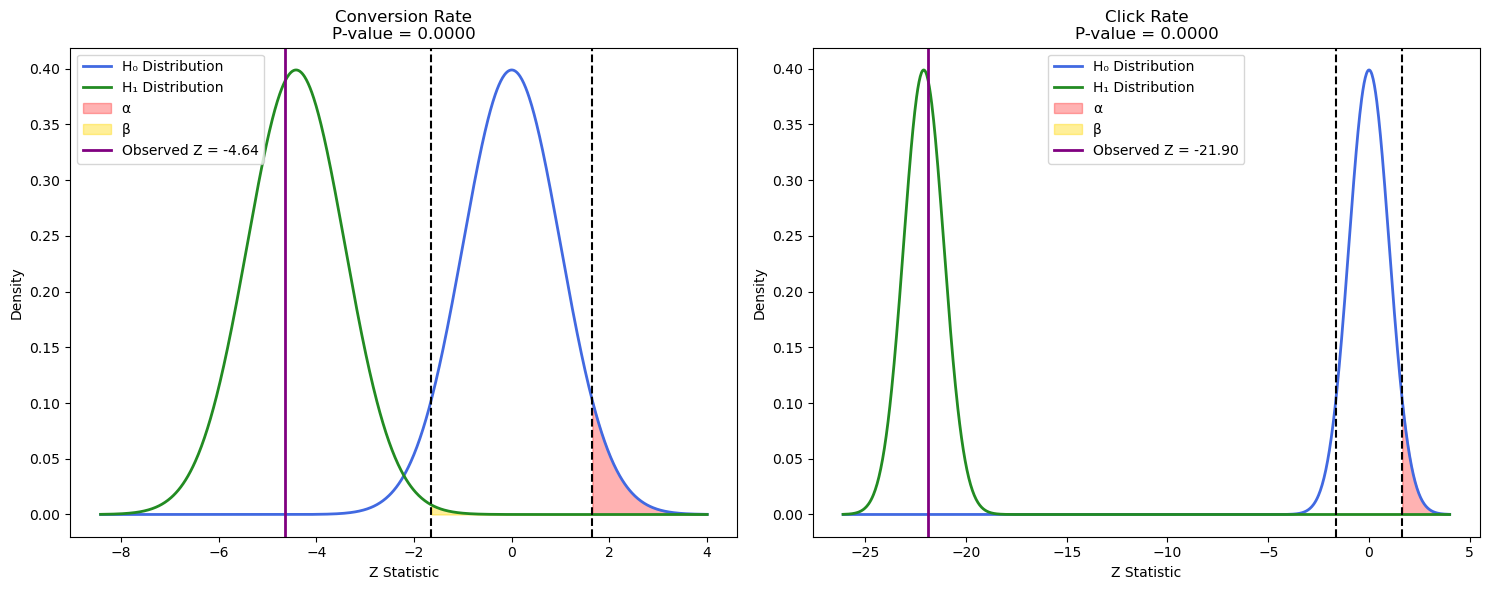

For /lander-2 failed to reject h0:The conversion rate of /home page and new landing page is same
Conversion Test for /lander-2 z_value: 1.600839, p_value: 0.10941251579882631
Click Test for /lander-2 z_value: -25.306085, p_value: 2.7377306106046106e-141

         Page   Conv  Clicks   Total
0  /lander-2  10128   71921  131170
1      /home   6927   55336   91891

type II error: 0.5157330280994045



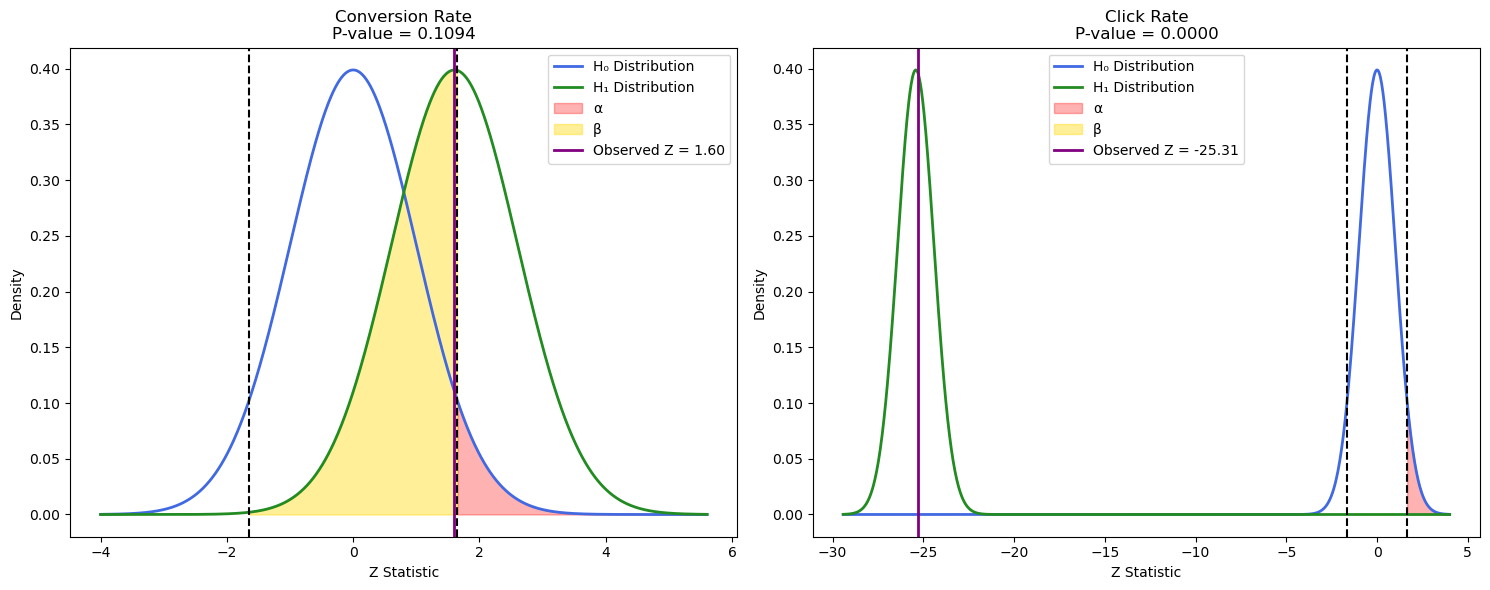

Conversion Test for /lander-3 z_value: -36.302502, p_value: 1.477328828622234e-288
Click Test for /lander-3 z_value: -42.767559, p_value: 0.0

         Page  Conv  Clicks  Total
0  /lander-3  2337   34614  69969
1      /home  6705   53080  88124

type II error: 0.0



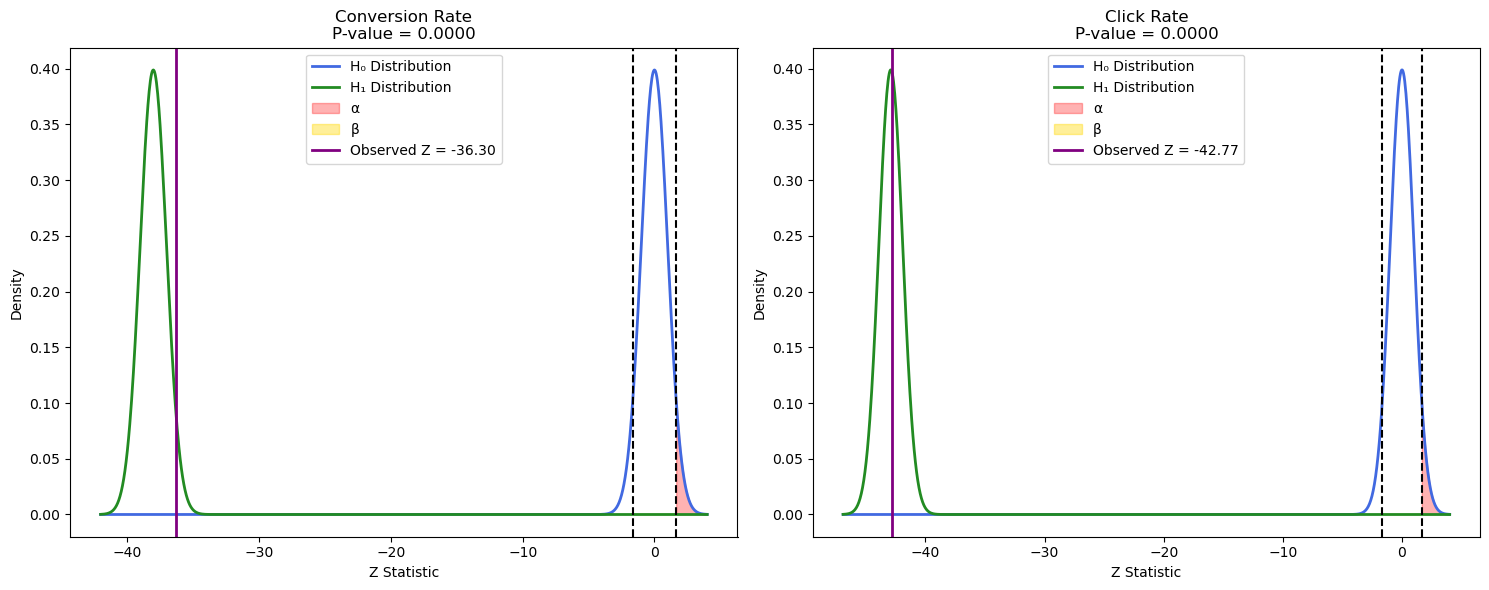

For /lander-4 failed to reject h0:The conversion rate of /home page and new landing page is same
Conversion Test for /lander-4 z_value: -0.928909, p_value: 0.352936189908325
Click Test for /lander-4 z_value: -17.838886, p_value: 3.5265575514106424e-71

         Page  Conv  Clicks  Total
0  /lander-4   708    4534   9385
1      /home   926    7114  11740

type II error: 0.757328635482232



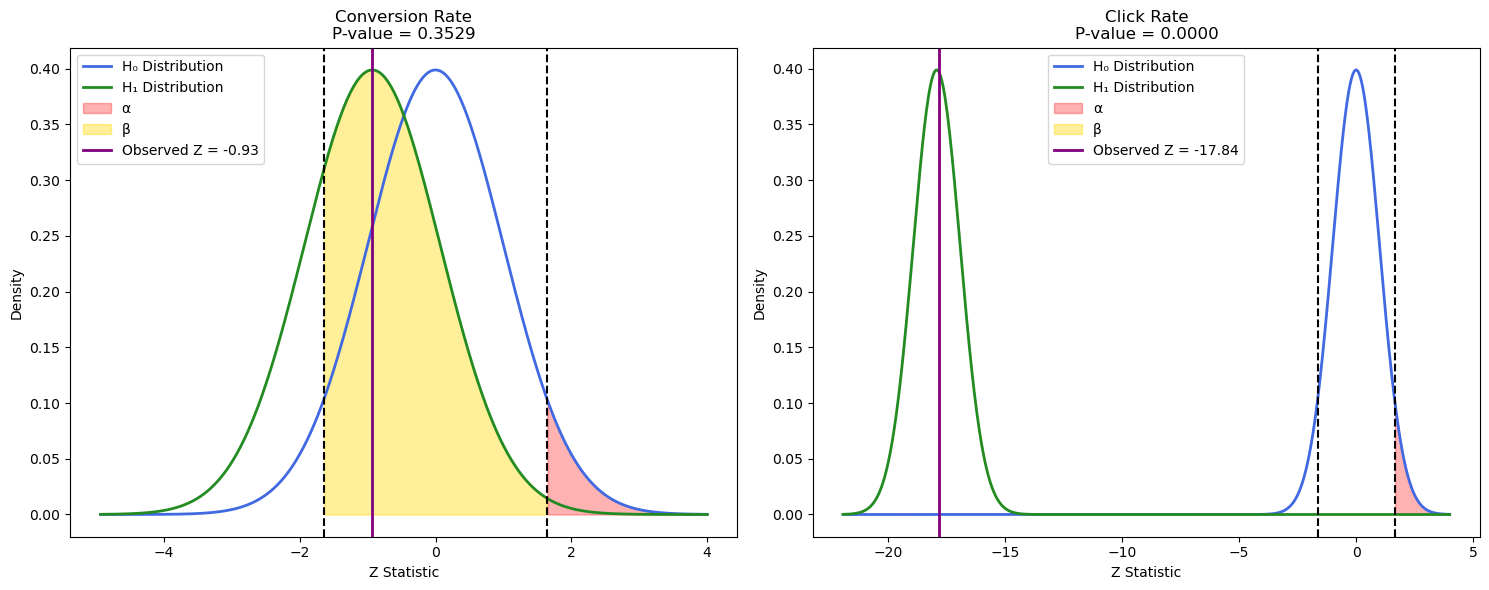

For /lander-5 rejected h0:The conversion rate of /home page and new landing page is same
For /lander-5 rejected h0:The click rate of /home page and new landing page is same
Conversion Test for /lander-5 z_value: 11.473884, p_value: 1.784647813637029e-30
Click Test for /lander-5 z_value: 8.444132, p_value: 3.063138330437151e-17

         Page  Conv  Clicks  Total
0  /lander-5  4375   27608  43865
1      /home  2968   23177  38582

type II error: 1.6292069371223094e-23



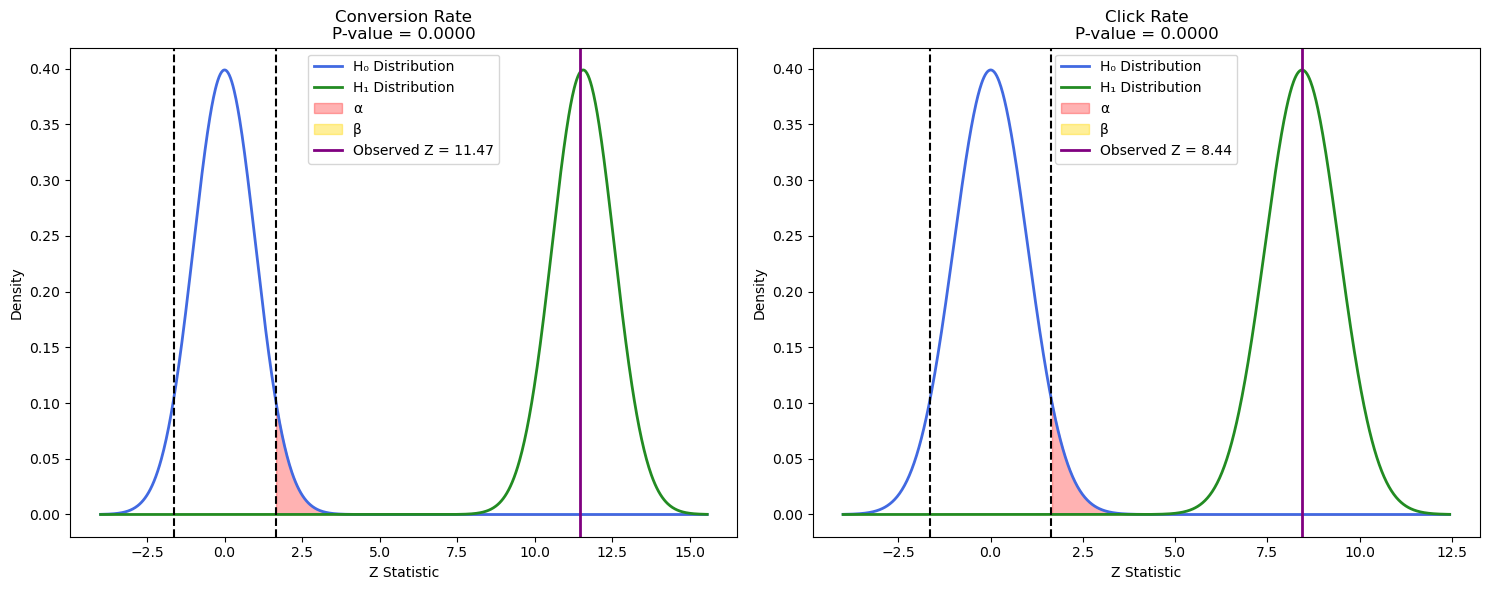

In [297]:
for i in pages:
    zconv,pconv,zclick,pclick,Conv_Table=prop_ztest(i)
    if pconv>alpha:
        print(f"For {i} failed to reject h0:{h_conv0}")
    elif zconv>norm.ppf(1 - alpha/2): 
        print(f"For {i} rejected h0:{h_conv0}")

    if pclick>alpha:
        print(f"For {i} failed to reject h0:{h_click0}")
    elif zconv>norm.ppf(1 - alpha/2): 
        print(f"For {i} rejected h0:{h_click0}")
        
    print(f"Conversion Test for {i} z_value: {zconv.round(6)}, p_value: {pconv}")
    print(f"Click Test for {i} z_value: {zclick.round(6)}, p_value: {pclick}\n")
    print(f" {Conv_Table}\n")
    print(f"type II error: {type2_error_prop_test(Conv_Table)}\n")
    plot_two_prop_ztest(i)